In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Analysis of Numerical Variables

In [2]:
df = pd.read_csv('data/data_cleaned_for_clustering.csv')
df.head()

,Unnamed: 0,age,job,day_of_week,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,default_status_known,was_previously_contacted,positive_campaign_result
0,0,56,housemaid,mon,1,0,no,no,no,-36.4,4.857,married,basic.4y,0,telephone,may,261,1,0,0
1,1,57,services,mon,1,0,no,no,unknown,-36.4,4.857,married,high.school,0,telephone,may,149,0,0,0
2,2,37,services,mon,1,0,yes,no,no,-36.4,4.857,married,high.school,0,telephone,may,226,1,0,0
3,3,40,admin.,mon,1,0,no,no,no,-36.4,4.857,married,basic.6y,0,telephone,may,151,1,0,0
4,4,56,services,mon,1,0,no,yes,no,-36.4,4.857,married,high.school,0,telephone,may,307,1,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 39803 non-null  int64  
 1   age                        39803 non-null  int64  
 2   job                        39803 non-null  object 
 3   day_of_week                39803 non-null  object 
 4   campaign                   39803 non-null  int64  
 5   term_deposit_subscribed    39803 non-null  int64  
 6   has_housing_loan           39803 non-null  object 
 7   has_personal_loan          39803 non-null  object 
 8   default_status             39803 non-null  object 
 9   consumer_confidence_index  39803 non-null  float64
 10  euribor_3mo_rate           39803 non-null  float64
 11  marital_status             39803 non-null  object 
 12  education_level            39803 non-null  object 
 13  previous_contacted         39803 non-null  int

In [4]:
# Count Unknown aka missing values by column

(df == 'unknown').sum()

Unnamed: 0                      0
age                             0
job                             0
day_of_week                     0
campaign                        0
term_deposit_subscribed         0
has_housing_loan                0
has_personal_loan               0
default_status               8213
consumer_confidence_index       0
euribor_3mo_rate                0
marital_status                  0
education_level                 0
previous_contacted              0
communication_type              0
last_contact_month              0
last_contact_duration_sec       0
default_status_known            0
was_previously_contacted        0
positive_campaign_result        0
dtype: int64

In [5]:
# Drop the additional index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Drop the default_status_known column, it will be redundant later
df = df.drop(columns=['default_status_known'], errors='ignore')

# Cast type 'object' columns as 'category' columns for better performance
df[df.select_dtypes('object').columns] = df.select_dtypes('object').astype('category')

# Prints and sums any duplicated rows in the dataset
df.duplicated().sum()

12

In [6]:
# Verify changes in data type and dropping of index
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        39803 non-null  int64   
 1   job                        39803 non-null  category
 2   day_of_week                39803 non-null  category
 3   campaign                   39803 non-null  int64   
 4   term_deposit_subscribed    39803 non-null  int64   
 5   has_housing_loan           39803 non-null  category
 6   has_personal_loan          39803 non-null  category
 7   default_status             39803 non-null  category
 8   consumer_confidence_index  39803 non-null  float64 
 9   euribor_3mo_rate           39803 non-null  float64 
 10  marital_status             39803 non-null  category
 11  education_level            39803 non-null  category
 12  previous_contacted         39803 non-null  int64   
 13  communication_type         3980

In [7]:
age_top_40 = df.groupby('age')['age'].count().sort_values(ascending=False).head(40)
age_top_40

age
31    1895
32    1779
33    1765
36    1734
35    1701
34    1695
30    1664
37    1440
29    1418
39    1402
38    1353
41    1230
40    1133
42    1112
45    1049
43    1018
46     992
44     980
28     971
48     954
47     884
50     831
27     823
49     808
52     747
51     731
53     697
56     679
26     678
54     667
57     620
55     614
25     582
58     556
24     442
59     441
60     266
23     220
22     131
21      98
Name: age, dtype: int64

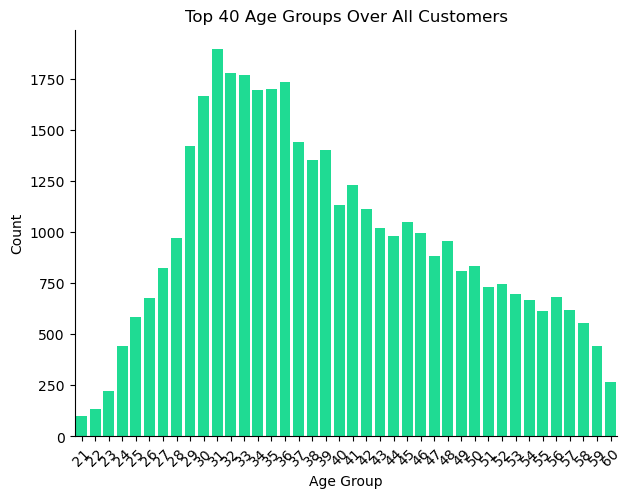

In [8]:
# Bar plot for top 20 age groups

sns.barplot(data=age_top_40, color='mediumspringgreen')
plt.tight_layout()
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.xlabel('Age Group')
sns.despine()
plt.title('Top 40 Age Groups Over All Customers')
plt.show()

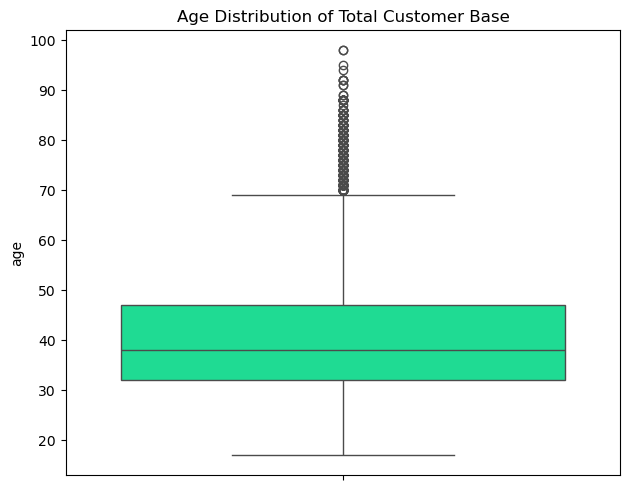

In [9]:
# Boxplot for age distribution of customer base

sns.boxplot(df['age'], color='mediumspringgreen')
plt.tight_layout()
plt.title('Age Distribution of Total Customer Base')
plt.show()

In [10]:
# Get only data of the td subscribers

td_sub = df[df['term_deposit_subscribed'] == 1]

# Number of 1 subscriptions per age, sorted descending
sub_by_age = (td_sub['age']
              .value_counts()
              .reset_index(name='sub_count')
              .rename(columns={'index': 'age'})
              .sort_values('sub_count', ascending=False)
              .head(40))
              
sub_by_age

,age,sub_count
0,31,213
1,33,207
2,30,195
3,34,183
4,29,183
5,32,176
6,35,163
7,36,148
8,28,146
9,38,140


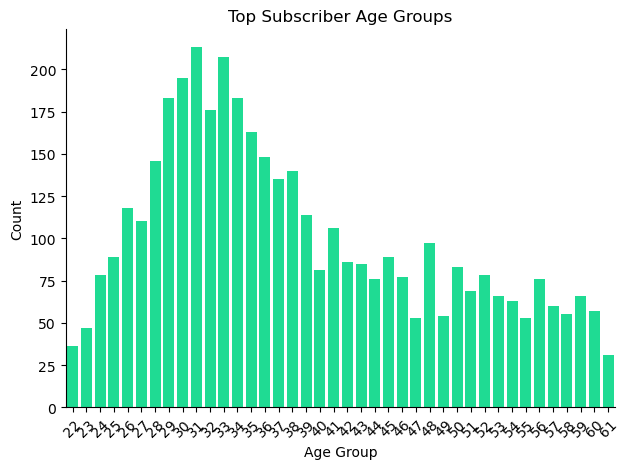

In [11]:
# Bar plot for top 20 subsrciber age groups

sns.barplot(data=sub_by_age, x='age', y='sub_count', color='mediumspringgreen')

plt.xticks(rotation=45)
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.title('Top Subscriber Age Groups')
sns.despine()
plt.tight_layout()
plt.show()

In [12]:
# Value Counts for term deposits

df['term_deposit_subscribed'].value_counts()

term_deposit_subscribed
0    35316
1     4487
Name: count, dtype: int64

In [13]:
# Shows values for number of times customers were previously contacted before this campaign

df['previous_contacted'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int64)

In [14]:
# Get Only customers who have subscribed

df_term_sub = df[df['term_deposit_subscribed'] == 1]
df_term_sub

,age,job,day_of_week,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,was_previously_contacted,positive_campaign_result
71,41,blue-collar,mon,1,1,yes,no,unknown,-36.4,4.857,divorced,basic.4y,0,telephone,may,1575,0,0
78,49,entrepreneur,mon,1,1,yes,no,unknown,-36.4,4.857,married,university.degree,0,telephone,may,1042,0,0
83,49,technician,mon,1,1,no,no,no,-36.4,4.857,married,basic.9y,0,telephone,may,1467,0,0
123,41,technician,mon,1,1,yes,no,unknown,-36.4,4.857,married,professional.course,0,telephone,may,579,0,0
133,45,blue-collar,mon,1,1,yes,no,unknown,-36.4,4.857,married,basic.9y,0,telephone,may,461,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39789,62,retired,thu,1,1,yes,no,no,-50.8,1.031,married,university.degree,6,cellular,nov,208,1,1
39793,62,retired,thu,2,1,no,no,no,-50.8,1.031,married,university.degree,3,cellular,nov,483,1,1
39796,37,admin.,fri,1,1,yes,no,no,-50.8,1.028,married,university.degree,0,cellular,nov,281,0,0
39798,73,retired,fri,1,1,yes,no,no,-50.8,1.028,married,professional.course,0,cellular,nov,334,0,0


In [15]:
# Get Only customers who have not subscribed

df_term_not_sub = df[df['term_deposit_subscribed'] == 0]
df_term_not_sub

,age,job,day_of_week,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,was_previously_contacted,positive_campaign_result
0,56,housemaid,mon,1,0,no,no,no,-36.4,4.857,married,basic.4y,0,telephone,may,261,0,0
1,57,services,mon,1,0,no,no,unknown,-36.4,4.857,married,high.school,0,telephone,may,149,0,0
2,37,services,mon,1,0,yes,no,no,-36.4,4.857,married,high.school,0,telephone,may,226,0,0
3,40,admin.,mon,1,0,no,no,no,-36.4,4.857,married,basic.6y,0,telephone,may,151,0,0
4,56,services,mon,1,0,no,yes,no,-36.4,4.857,married,high.school,0,telephone,may,307,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39795,36,admin.,fri,2,0,no,no,no,-50.8,1.028,married,university.degree,0,cellular,nov,254,0,0
39797,29,unemployed,fri,1,0,yes,no,no,-50.8,1.028,single,basic.4y,1,cellular,nov,112,1,1
39799,46,blue-collar,fri,1,0,no,no,no,-50.8,1.028,married,professional.course,0,cellular,nov,383,0,0
39800,56,retired,fri,2,0,yes,no,no,-50.8,1.028,married,university.degree,0,cellular,nov,189,0,0


In [16]:
# Contact number counts for subscibers

df_term_sub.groupby('previous_contacted')['previous_contacted'].sum()

previous_contacted
0      0
1    930
2    660
3    372
4    144
5     65
6     18
Name: previous_contacted, dtype: int64

In [17]:
# Contact number counts for non-subscibers

df_term_not_sub.groupby('previous_contacted')['previous_contacted'].sum()

previous_contacted
0       0
1    3482
2     784
3     249
4     120
5      25
6      12
7       7
Name: previous_contacted, dtype: int64

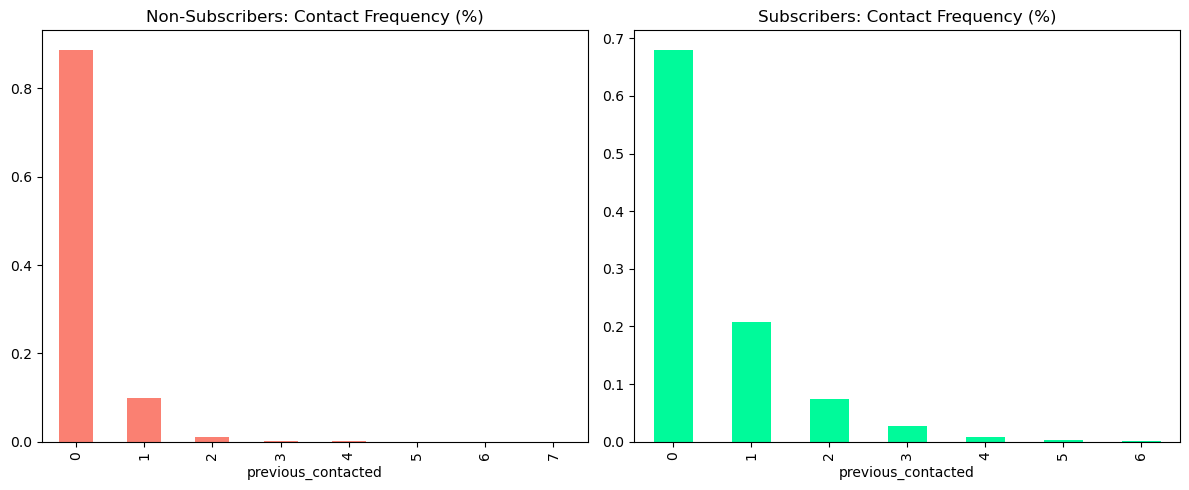

In [18]:
# Compare contact rates of non-subscribers and subscribers using % of total for fair comparison not skewed by group size

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

(df_term_not_sub['previous_contacted'].value_counts(normalize=True).sort_index()).plot(
    kind='bar', ax=axes[0], color='salmon',
    title='Non-Subscribers: Contact Frequency (%)'
)

(df_term_sub['previous_contacted'].value_counts(normalize=True).sort_index()).plot(
    kind='bar', ax=axes[1], color='mediumspringgreen',
    title='Subscribers: Contact Frequency (%)'
)

plt.tight_layout()
plt.show()

In [19]:
# Count of previous contacted by subscriber/non-subscriber
# Use value counts to see if group size is having an effect on total count

df.groupby('term_deposit_subscribed')['previous_contacted'].sum()

term_deposit_subscribed
0    4679
1    2189
Name: previous_contacted, dtype: int64

In [20]:
# Non subcriber group is much larger therefore has larger total count
# Use mean to aggregate for clearer picture of subscriber by contacted rate

df['term_deposit_subscribed'].value_counts()

term_deposit_subscribed
0    35316
1     4487
Name: count, dtype: int64

In [21]:
# Mean contacted rate of subscribers shows that those who subscribed were contactd nearly 4x the rate of non

sub_contact_rate = df.groupby('term_deposit_subscribed')['previous_contacted'].mean()
sub_contact_rate

term_deposit_subscribed
0    0.132490
1    0.487854
Name: previous_contacted, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\509045940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_contact_rate.index, y=sub_contact_rate.values,


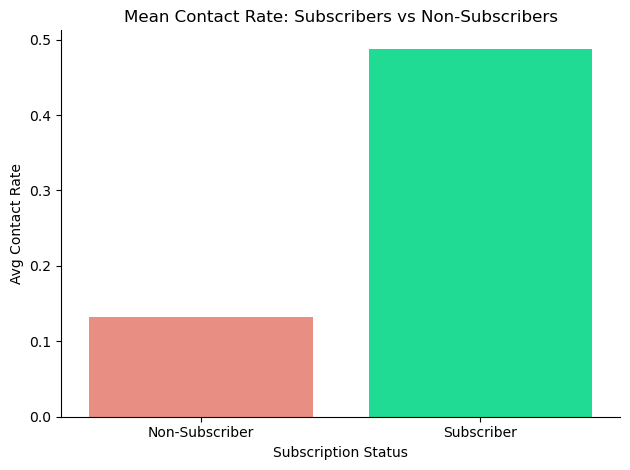

In [22]:
# Comparison of contact rate of sub vs non-sub


sns.barplot(x=sub_contact_rate.index, y=sub_contact_rate.values, 
            palette={'0': 'salmon', '1': 'mediumspringgreen'})

plt.xticks(ticks=[0, 1], labels=['Non-Subscriber', 'Subscriber'])
plt.ylabel('Avg Contact Rate')
plt.xlabel('Subscription Status')
plt.title('Mean Contact Rate: Subscribers vs Non-Subscribers')
sns.despine()
plt.tight_layout()
plt.show()

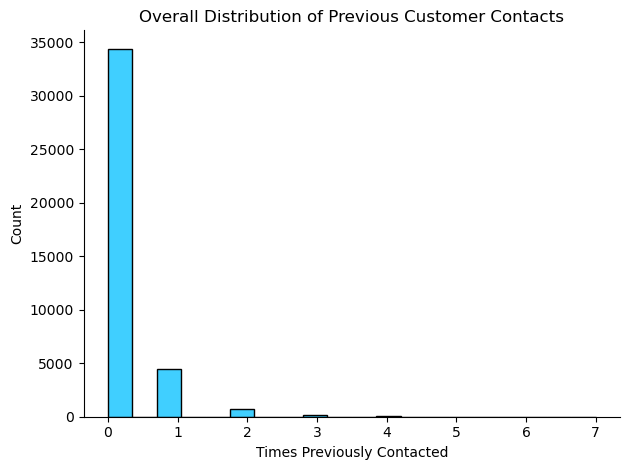

In [23]:
# Overall distribution of times a customer was previously contacted

sns.histplot(data=df, x='previous_contacted', bins=20, color='deepskyblue')

plt.ylabel('Count')
plt.xlabel('Times Previously Contacted')
plt.title('Overall Distribution of Previous Customer Contacts')
sns.despine()
plt.tight_layout()
plt.show()

In [24]:
df.groupby('previous_contacted')['previous_contacted'].count()

previous_contacted
0    34372
1     4412
2      722
3      207
4       66
5       18
6        5
7        1
Name: previous_contacted, dtype: int64

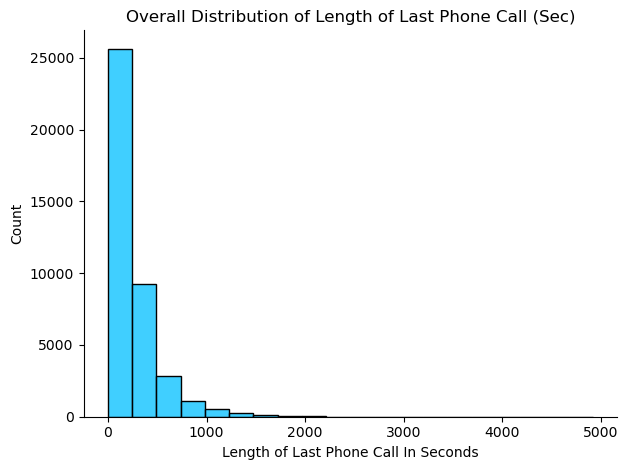

In [25]:
# Overall Distribution for length of last phone call in seconds 

sns.histplot(data=df, x='last_contact_duration_sec', bins=20, color='deepskyblue')

plt.ylabel('Count')
plt.xlabel('Length of Last Phone Call In Seconds')
plt.title('Overall Distribution of Length of Last Phone Call (Sec)')
sns.despine()
plt.tight_layout()
plt.show()

In [26]:
# Mean contacted rate of subscribers shows that those who subscribed were contactd nearly 4x the rate of non

sub_call_time = df.groupby('term_deposit_subscribed')['last_contact_duration_sec'].mean()
sub_call_time

term_deposit_subscribed
0    221.092309
1    553.271897
Name: last_contact_duration_sec, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\96257516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_call_time.index, y=sub_call_time.values,


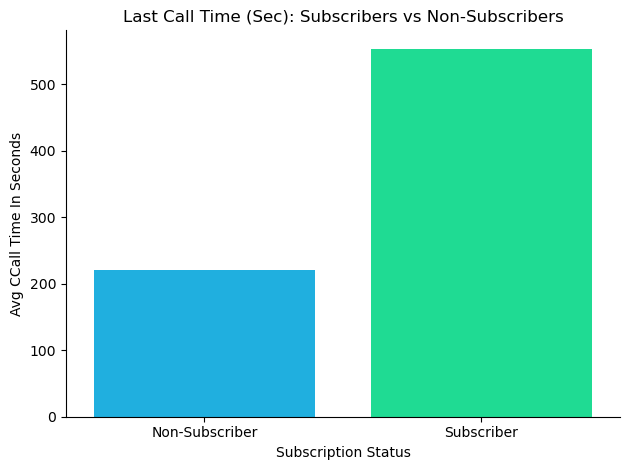

In [27]:
# Comparison of last call time sec of sub vs non-sub


sns.barplot(x=sub_call_time.index, y=sub_call_time.values, 
            palette={'0': 'deepskyblue', '1': 'mediumspringgreen'})

plt.xticks(ticks=[0, 1], labels=['Non-Subscriber', 'Subscriber'])
plt.ylabel('Avg CCall Time In Seconds')
plt.xlabel('Subscription Status')
plt.title('Last Call Time (Sec): Subscribers vs Non-Subscribers')
sns.despine()
plt.tight_layout()
plt.show()

In [28]:
df.columns

Index(['age', 'job', 'day_of_week', 'campaign', 'term_deposit_subscribed',
       'has_housing_loan', 'has_personal_loan', 'default_status',
       'consumer_confidence_index', 'euribor_3mo_rate', 'marital_status',
       'education_level', 'previous_contacted', 'communication_type',
       'last_contact_month', 'last_contact_duration_sec',
       'was_previously_contacted', 'positive_campaign_result'],
      dtype='object')

In [29]:
# Avg consumer confidence index for each day of the week

df.groupby('day_of_week')['consumer_confidence_index'].mean()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\27258935.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day_of_week')['consumer_confidence_index'].mean()


day_of_week
fri   -40.540459
mon   -40.888931
thu   -40.757540
tue   -40.061254
wed   -40.322021
Name: consumer_confidence_index, dtype: float64

In [112]:
# Euribor by Last Contact Month

euribor_by_month = df.groupby('last_contact_month')['euribor_3mo_rate'].mean().sort_values(ascending=False)
euribor_by_month

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\178665971.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  euribor_by_month = df.groupby('last_contact_month')['euribor_3mo_rate'].mean().sort_values(ascending=False)


last_contact_month
jul    4.687550
aug    4.305203
jun    4.258348
nov    3.725849
may    3.280899
apr    1.360288
oct    1.205197
mar    1.164202
dec    0.872230
sep    0.834676
Name: euribor_3mo_rate, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\562136765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=euribor_by_month.index, y=euribor_by_month.values, palette='mako')


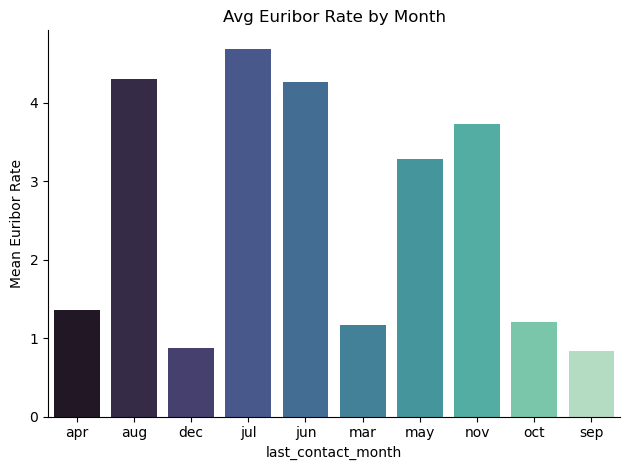

In [113]:
# Plot for euribor by month

sns.barplot(x=euribor_by_month.index, y=euribor_by_month.values, palette='mako')

plt.title('Avg Euribor Rate by Month')
plt.ylabel('Mean Euribor Rate')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Euribor by day of Week

df.groupby('day_of_week')['euribor_3mo_rate'].mean()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\666792832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day_of_week')['euribor_3mo_rate'].mean()


day_of_week
fri    3.562115
mon    3.542487
thu    3.570428
tue    3.704443
wed    3.719775
Name: euribor_3mo_rate, dtype: float64

In [31]:
# Mean Contact rates for subscribers vs non-suscribers

prev_contacted = df.groupby("was_previously_contacted")['term_deposit_subscribed'].mean()
prev_contacted

was_previously_contacted
0    0.092706
1    0.640110
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1192670864.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prev_contacted.index, y=prev_contacted.values,


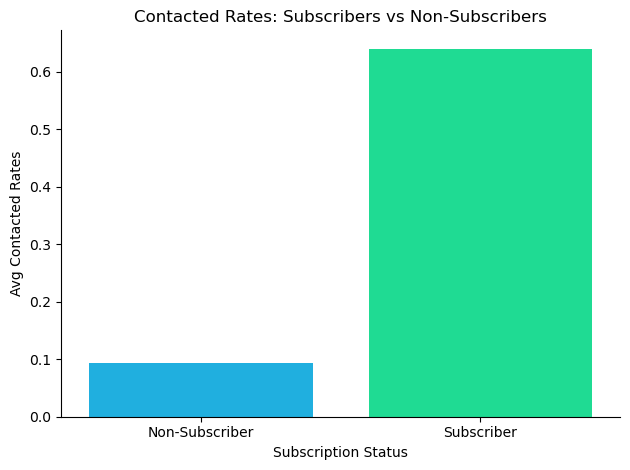

In [32]:
# Comparison of contact rates for sub vs non-sub


sns.barplot(x=prev_contacted.index, y=prev_contacted.values, 
            palette={'0': 'deepskyblue', '1': 'mediumspringgreen'})

plt.xticks(ticks=[0, 1], labels=['Non-Subscriber', 'Subscriber'])
plt.ylabel('Avg Contacted Rates')
plt.xlabel('Subscription Status')
plt.title('Contacted Rates: Subscribers vs Non-Subscribers')
sns.despine()
plt.tight_layout()
plt.show()

In [33]:
# Mean age for subscribers vs non-suscribers

df.groupby("term_deposit_subscribed")['age'].mean()

term_deposit_subscribed
0    39.867822
1    40.864943
Name: age, dtype: float64

# Analysis of Categorical Variables

In [34]:
# Overall count of jobs in the data

job_count = df.groupby('job')['job'].count().sort_values(ascending=False)
job_count

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\2383656649.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_count = df.groupby('job')['job'].count().sort_values(ascending=False)


job
admin.           10181
blue-collar       9001
technician        6584
services          3862
management        2850
retired           1671
entrepreneur      1417
self-employed     1376
housemaid         1028
unemployed         982
student            851
Name: job, dtype: int64

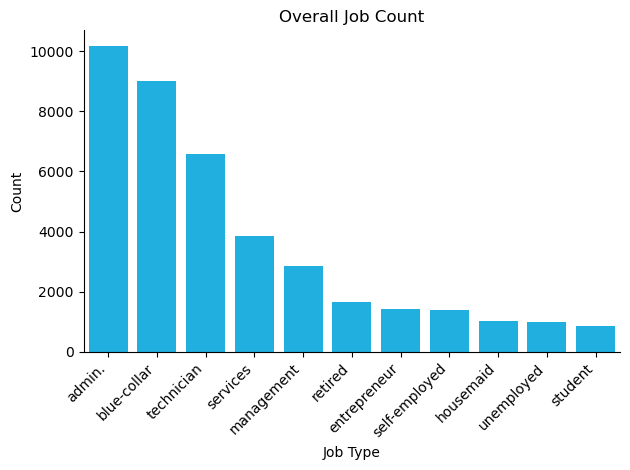

In [35]:
# Frequency of jobs

sns.barplot(x=job_count.index, y=job_count.values, order=job_count.index, color='deepskyblue')

plt.ylabel('Count')
plt.xlabel('Job Type')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns the labels
plt.title('Overall Job Count')
sns.despine()
plt.tight_layout()
plt.show()

In [36]:
# Count of term dep subscribers by job type

job_type_sub = df_term_sub.groupby('job')['term_deposit_subscribed'].count().sort_values(ascending=False)
job_type_sub

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\690089974.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_type_sub = df_term_sub.groupby('job')['term_deposit_subscribed'].count().sort_values(ascending=False)


job
admin.           1321
technician        707
blue-collar       619
retired           423
management        324
services          316
student           264
self-employed     147
unemployed        143
entrepreneur      120
housemaid         103
Name: term_deposit_subscribed, dtype: int64

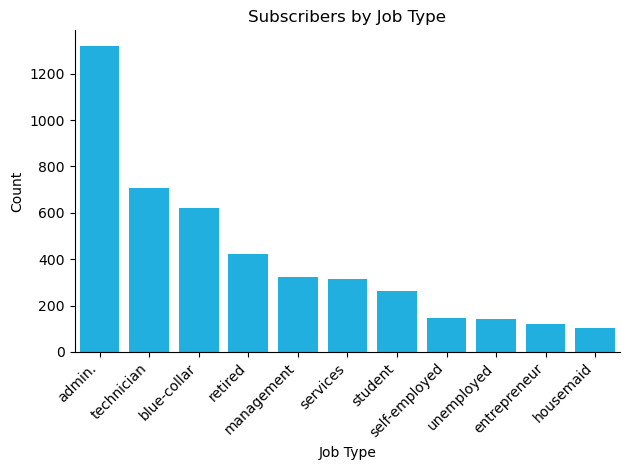

In [37]:
# Subscribers by job type

sns.barplot(x=job_type_sub.index, y=job_type_sub.values, order=job_type_sub.index, color='deepskyblue')

plt.ylabel('Count')
plt.xlabel('Job Type')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns the labels
plt.title('Subscribers by Job Type')
sns.despine()
plt.tight_layout()
plt.show()

In [38]:
# Count of term dep non subscribers by job type

job_type_non_sub = df_term_not_sub.groupby('job')['term_deposit_subscribed'].count().sort_values(ascending=False)
job_type_non_sub

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\2397126815.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_type_non_sub = df_term_not_sub.groupby('job')['term_deposit_subscribed'].count().sort_values(ascending=False)


job
admin.           8860
blue-collar      8382
technician       5877
services         3546
management       2526
entrepreneur     1297
retired          1248
self-employed    1229
housemaid         925
unemployed        839
student           587
Name: term_deposit_subscribed, dtype: int64

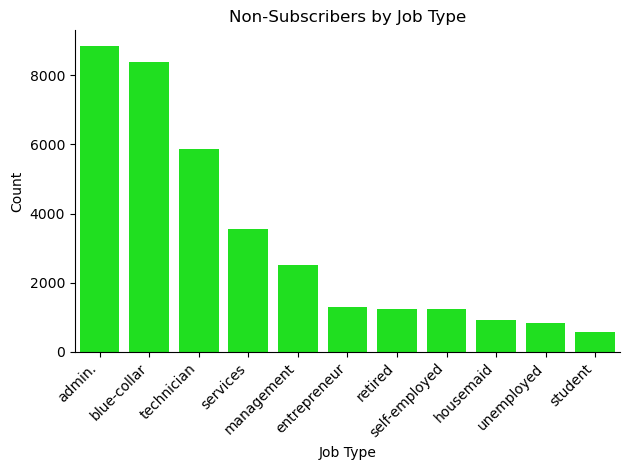

In [39]:
# Non-Subscribers by job type

sns.barplot(x=job_type_non_sub.index, y=job_type_non_sub.values, order=job_type_non_sub.index, color='lime')

plt.ylabel('Count')
plt.xlabel('Job Type')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns the labels
plt.title('Non-Subscribers by Job Type')
sns.despine()
plt.tight_layout()
plt.show()

In [40]:
df.columns

Index(['age', 'job', 'day_of_week', 'campaign', 'term_deposit_subscribed',
       'has_housing_loan', 'has_personal_loan', 'default_status',
       'consumer_confidence_index', 'euribor_3mo_rate', 'marital_status',
       'education_level', 'previous_contacted', 'communication_type',
       'last_contact_month', 'last_contact_duration_sec',
       'was_previously_contacted', 'positive_campaign_result'],
      dtype='object')

In [41]:
# Missing value for default status

missing_default_status = df['default_status'] == 'unknown'
missing_default_status.sum()

8213

In [42]:
df['default_status'].value_counts()

default_status
no         31587
unknown     8213
yes            3
Name: count, dtype: int64

In [43]:
# Customers in default

in_default = (df['default_status'] == 'yes')
in_default.sum()

3

In [44]:
# Overall frequencies for education levels

education_levels = df.groupby('education_level')['education_level'].count().sort_values(ascending=False)
education_levels

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1950741243.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_levels = df.groupby('education_level')['education_level'].count().sort_values(ascending=False)


education_level
university.degree      12290
high.school             9553
basic.9y                6297
professional.course     5304
basic.4y                4137
basic.6y                2204
illiterate                18
Name: education_level, dtype: int64

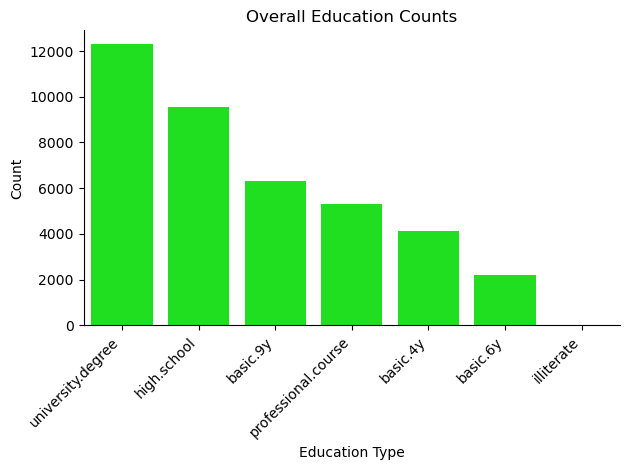

In [45]:
# Education Levels

sns.barplot(x=education_levels.index, y=education_levels.values, order=education_levels.index, color='lime')

plt.ylabel('Count')
plt.xlabel('Education Type')
plt.xticks(rotation=45, ha='right')  # ha='right' aligns the labels
plt.title('Overall Education Counts')
sns.despine()
plt.tight_layout()
plt.show()

In [46]:
# Job counts by education

job_by_education = df.pivot_table(index='education_level', 
                                  columns='job', 
                                  aggfunc='size', 
                                  fill_value=0)

# Correct way to add total column
job_by_education['total'] = job_by_education.sum(axis=1)

# Sort by total (highest education level count first)
job_by_education = job_by_education.sort_values(by='total', ascending=False)

print(job_by_education)

job                  admin.  blue-collar  entrepreneur  housemaid  management  \
education_level                                                                 
university.degree      5867           92           651        133        2131   
high.school            3245          858           227        170         291   
basic.9y                490         3962           207         92         161   
professional.course     355          443           129         59          85   
basic.4y                 75         2253           132        500          97   
basic.6y                148         1385            69         73          85   
illiterate                1            8             2          1           0   

job                  retired  self-employed  services  student  technician  \
education_level                                                              
university.degree        278            772       164      165        1765   
high.school              267        

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3488892208.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  job_by_education = df.pivot_table(index='education_level',


<Figure size 1400x800 with 0 Axes>

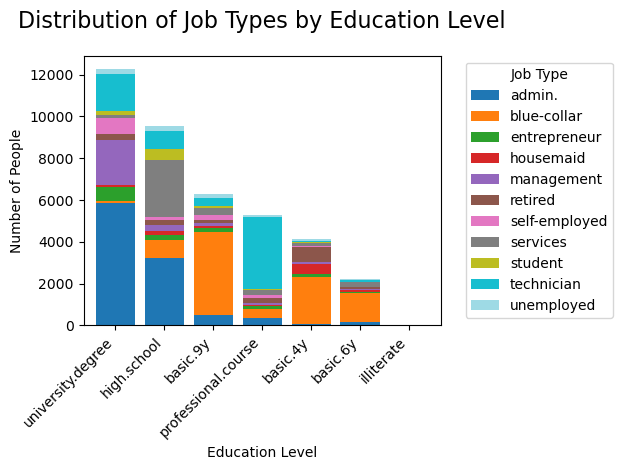

In [47]:
# Counts of job types by educaiton levels

job_by_education = job_by_education.sort_values(by='total', ascending=False)

# Drop the total column for plotting
plot_data = job_by_education.drop(columns='total')

plt.figure(figsize=(14, 8))
plot_data.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.title('Distribution of Job Types by Education Level', fontsize=16, pad=20)
plt.xlabel('Education Level')
plt.ylabel('Number of People')
plt.legend(title='Job Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



<Figure size 1400x800 with 0 Axes>

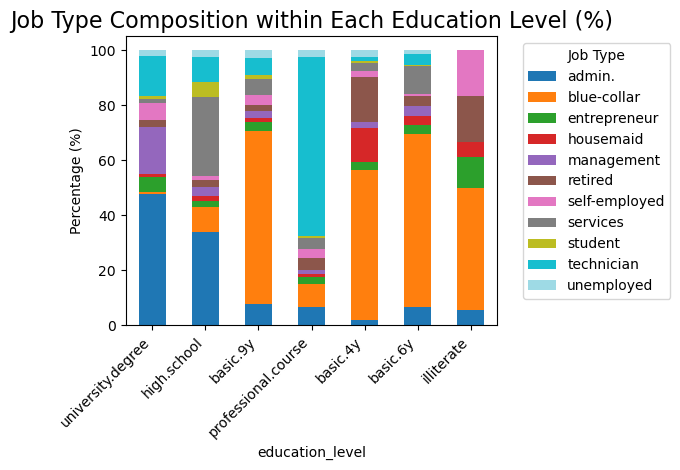

In [48]:
# Percentage of totoal jobs by education


pct_data = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
pct_data.plot(kind='bar', stacked=True, colormap='tab20')
plt.title('Job Type Composition within Each Education Level (%)', fontsize=16)
plt.ylabel('Percentage (%)')
plt.legend(title='Job Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
# term deposit counts by education pivot table

term_dep_by_education = df.pivot_table(index='education_level', 
                                  columns='term_deposit_subscribed', 
                                  aggfunc='size', 
                                  fill_value=0)

# Correct way to add total column
term_dep_by_education['total'] = term_dep_by_education.sum(axis=1)

# Sort by total (highest education level count first)
term_dep_by_education = term_dep_by_education.sort_values(by='total', ascending=False)

print(term_dep_by_education)

term_deposit_subscribed      0     1  total
education_level                            
university.degree        10602  1688  12290
high.school               8471  1082   9553
basic.9y                  5816   481   6297
professional.course       4702   602   5304
basic.4y                  3687   450   4137
basic.6y                  2024   180   2204
illiterate                  14     4     18


C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1966171128.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  term_dep_by_education = df.pivot_table(index='education_level',


<Figure size 1400x800 with 0 Axes>

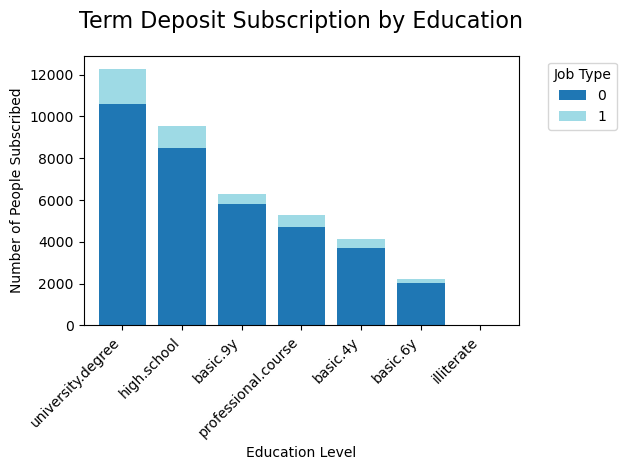

In [50]:
# Term deposit subscriptions by education


term_dep_by_education = term_dep_by_education.sort_values(by='total', ascending=False)

# Drop the total column for plotting
plot_data = term_dep_by_education.drop(columns='total')

plt.figure(figsize=(14, 8))
plot_data.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.title('Term Deposit Subscription by Education', fontsize=16, pad=20)
plt.xlabel('Education Level')
plt.ylabel('Number of People Subscribed')
plt.legend(title='Job Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [51]:
# Count of last contact by month


last_contact_month = df.groupby('last_contact_month')['last_contact_month'].count().sort_index()
last_contact_month


month_order_abbr = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
                    'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

last_contact_month = last_contact_month.reindex(month_order_abbr)

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1200060241.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last_contact_month = df.groupby('last_contact_month')['last_contact_month'].count().sort_index()


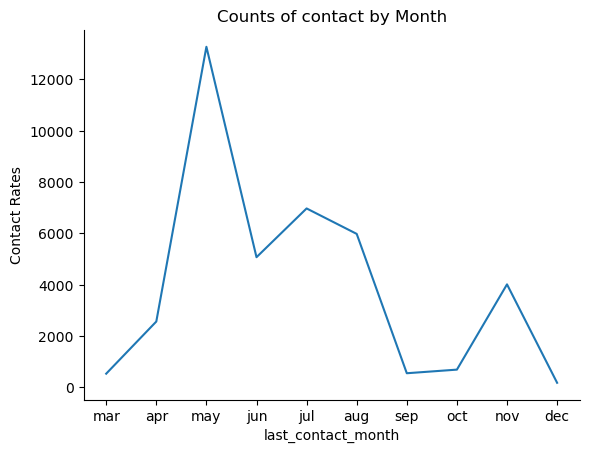

In [52]:
# Counts of last contact by month

sns.lineplot(x=last_contact_month.index, y=last_contact_month.values)
plt.title('Counts of contact by Month')
plt.ylabel('Contact Rates')
sns.despine()
plt.show()

In [114]:
# Count of marital status categories

marital_status = df.groupby('marital_status')['marital_status'].count().sort_values(ascending=False)
marital_status


C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3803239526.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marital_status = df.groupby('marital_status')['marital_status'].count().sort_values(ascending=False)


marital_status
married     24110
single      11215
divorced     4478
Name: marital_status, dtype: int64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\738781378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_status.index, y=marital_status.values, palette='mako')


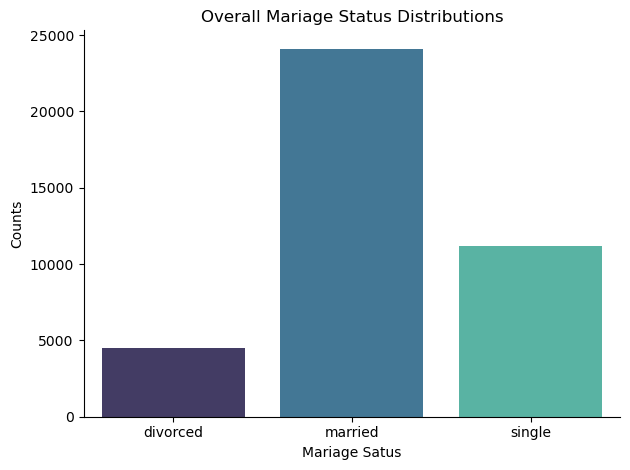

In [121]:
# Plot of Marital Status

sns.barplot(x=marital_status.index, y=marital_status.values, palette='mako')
plt.title('Overall Mariage Status Distributions')
plt.ylabel('Counts')
plt.xlabel('Mariage Satus')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Count of default status categories

df.groupby('default_status')['default_status'].count()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\516583875.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('default_status')['default_status'].count()


default_status
no         31587
unknown     8213
yes            3
Name: default_status, dtype: int64

In [55]:
# Count of has housing loan categories

df.groupby('has_housing_loan')['has_housing_loan'].count()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3945714383.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('has_housing_loan')['has_housing_loan'].count()


has_housing_loan
no     18427
yes    21376
Name: has_housing_loan, dtype: int64

In [56]:
# Count of has personal loan categories

df.groupby('has_personal_loan')['has_personal_loan'].count()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1817711249.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('has_personal_loan')['has_personal_loan'].count()


has_personal_loan
no     33620
yes     6183
Name: has_personal_loan, dtype: int64

In [57]:
# Count of communication categories

df.groupby('communication_type')['communication_type'].count()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\796239639.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('communication_type')['communication_type'].count()


communication_type
cellular     25369
telephone    14434
Name: communication_type, dtype: int64

In [58]:
# Count of day of week categories

df.groupby('day_of_week')['day_of_week'].count().sort_values(ascending=False)

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\908176336.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day_of_week')['day_of_week'].count().sort_values(ascending=False)


day_of_week
thu    8342
mon    8230
wed    7856
tue    7797
fri    7578
Name: day_of_week, dtype: int64

# Target Variable

In [59]:
# Percent of subscribed vs not subscribed

term_dep_rate = df['term_deposit_subscribed'].value_counts()/ len(df['term_deposit_subscribed'])
term_dep_rate

term_deposit_subscribed
0    0.88727
1    0.11273
Name: count, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1383183464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=term_dep_rate, palette='mako')


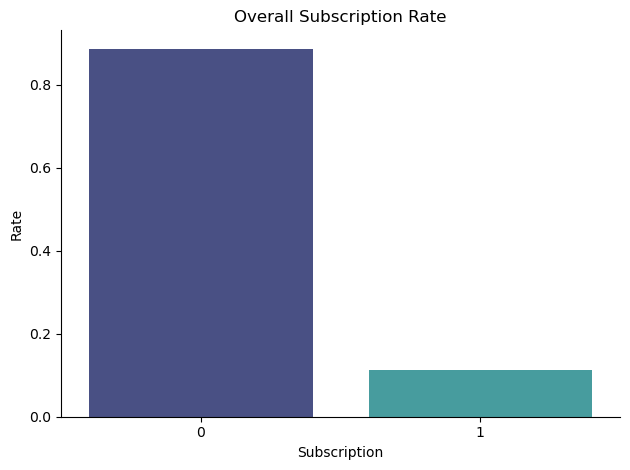

In [122]:
# Overall Subscription rates

sns.barplot(data=term_dep_rate, palette='mako')
plt.title('Overall Subscription Rate')
plt.ylabel('Rate')
plt.xlabel('Subscription')
sns.despine()
plt.tight_layout()
plt.show()


In [61]:
# Percent of positive campaign result vs not

pos_campaign_rate = df['positive_campaign_result'].value_counts() / len(df['positive_campaign_result'])
pos_campaign_rate

positive_campaign_result
0    0.863553
1    0.136447
Name: count, dtype: float64

<Axes: xlabel='positive_campaign_result', ylabel='count'>

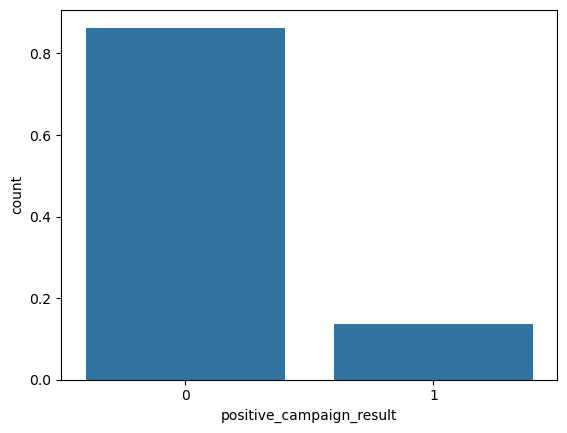

In [62]:
sns.barplot(data=pos_campaign_rate)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   age                        39803 non-null  int64   
 1   job                        39803 non-null  category
 2   day_of_week                39803 non-null  category
 3   campaign                   39803 non-null  int64   
 4   term_deposit_subscribed    39803 non-null  int64   
 5   has_housing_loan           39803 non-null  category
 6   has_personal_loan          39803 non-null  category
 7   default_status             39803 non-null  category
 8   consumer_confidence_index  39803 non-null  float64 
 9   euribor_3mo_rate           39803 non-null  float64 
 10  marital_status             39803 non-null  category
 11  education_level            39803 non-null  category
 12  previous_contacted         39803 non-null  int64   
 13  communication_type         3980

# **---Deeper Analysis---**

In [64]:
# Count of education type by cluster

edu_by_cluster = df.groupby(['marital_status', 'education_level'])['education_level'].size().reset_index(name='count')
edu_by_cluster

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1854386146.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_by_cluster = df.groupby(['marital_status', 'education_level'])['education_level'].size().reset_index(name='count')


,marital_status,education_level,count
0,divorced,basic.4y,496
1,divorced,basic.6y,174
2,divorced,basic.9y,605
3,divorced,high.school,1182
4,divorced,illiterate,2
5,divorced,professional.course,669
6,divorced,university.degree,1350
7,married,basic.4y,3202
8,married,basic.6y,1712
9,married,basic.9y,4340


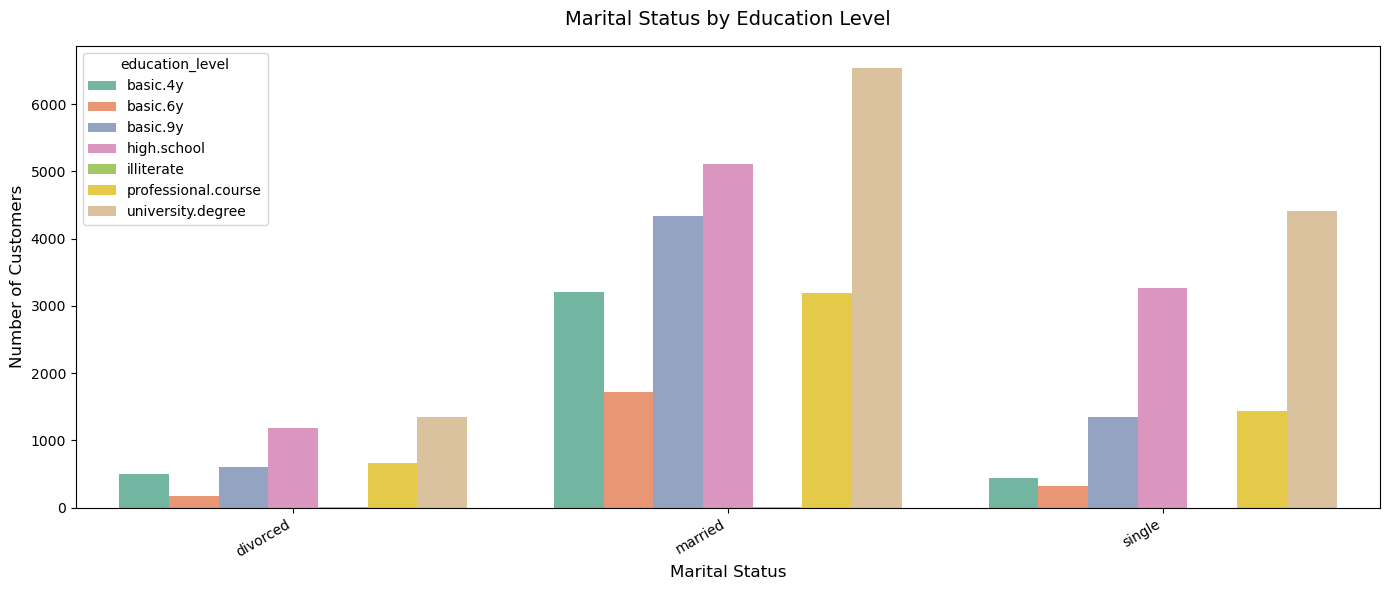

In [65]:
# Education Level by Marital Status

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=edu_by_cluster,
    x='marital_status',    # education on x-axis
    y='count',              # bar height = count
    hue='education_level',          # grouped by cluster (0, 1, 2)
    palette='Set2',
    errorbar=None
)

ax.set_title('Marital Status by Education Level', fontsize=14, pad=15)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [66]:
# Default Status by educatino level

default_by_education = df.groupby(['education_level', 'default_status'])['default_status'].size().reset_index(name='count')
default_by_education

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3473881693.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_education = df.groupby(['education_level', 'default_status'])['default_status'].size().reset_index(name='count')


,education_level,default_status,count
0,basic.4y,no,2483
1,basic.4y,unknown,1654
2,basic.4y,yes,0
3,basic.6y,no,1389
4,basic.6y,unknown,815
5,basic.6y,yes,0
6,basic.9y,no,4532
7,basic.9y,unknown,1765
8,basic.9y,yes,0
9,high.school,no,7945


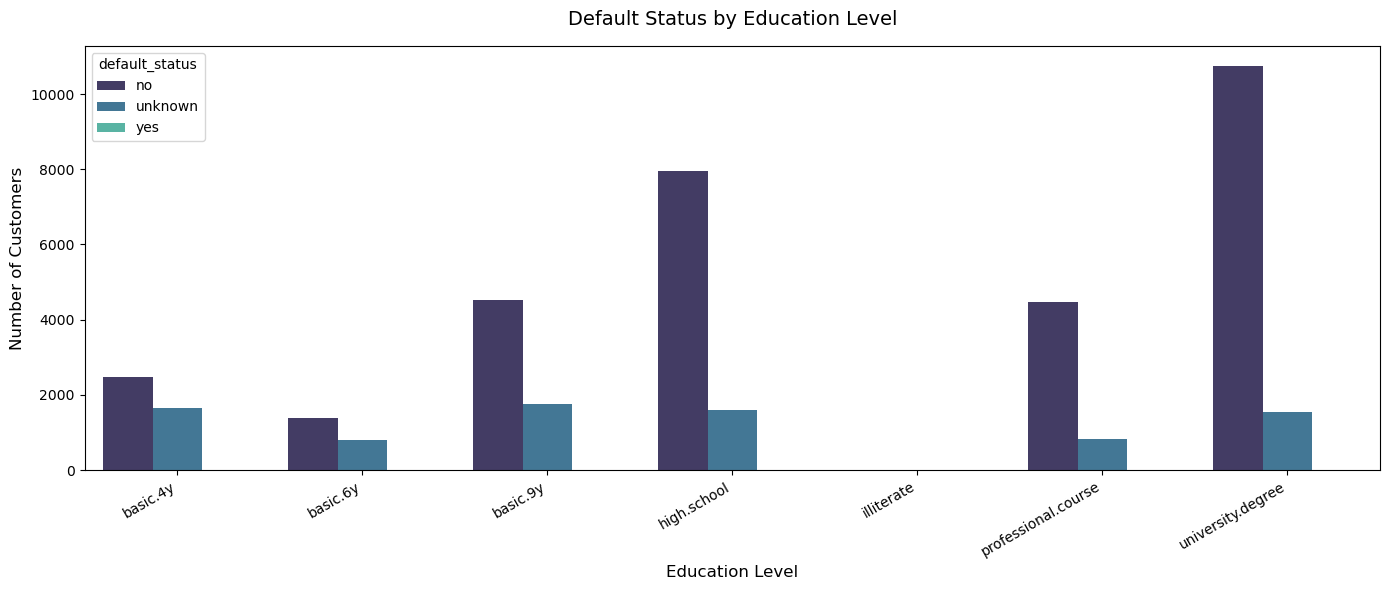

In [67]:
# Default status by education level

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=default_by_education,
    x='education_level',    # education on x-axis
    y='count',              # bar height = count
    hue='default_status',          # grouped by cluster (0, 1, 2)
    palette='mako',
    errorbar=None
)

ax.set_title('Default Status by Education Level', fontsize=14, pad=15)
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [68]:
# Overall subscription rates

overall_sub_rate = df.groupby('term_deposit_subscribed')['term_deposit_subscribed'].count() / len(df) * 100
overall_sub_rate = overall_sub_rate.round(3)
overall_sub_rate

term_deposit_subscribed
0    88.727
1    11.273
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3781222335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=overall_sub_rate.index, y=overall_sub_rate.values, palette='mako', order=overall_sub_rate.index)


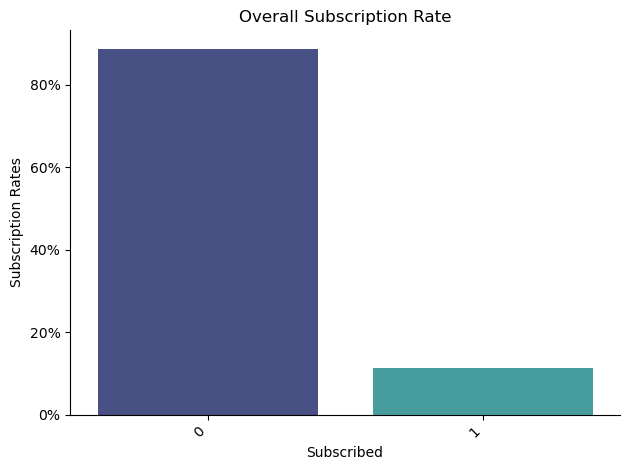

In [69]:
import matplotlib.ticker as mticker

ax = sns.barplot(x=overall_sub_rate.index, y=overall_sub_rate.values, palette='mako', order=overall_sub_rate.index)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.xticks(rotation=45, ha='right')
plt.title('Overall Subscription Rate')
plt.ylabel("Subscription Rates")
plt.xlabel("Subscribed")
sns.despine()
plt.tight_layout()
plt.show()

In [70]:
# Home Loans by education level

home_loan_by_education = df.groupby(['education_level', 'has_housing_loan'])['has_housing_loan'].size().reset_index(name='count')
home_loan_by_education

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\432439572.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  home_loan_by_education = df.groupby(['education_level', 'has_housing_loan'])['has_housing_loan'].size().reset_index(name='count')


,education_level,has_housing_loan,count
0,basic.4y,no,1991
1,basic.4y,yes,2146
2,basic.6y,no,1048
3,basic.6y,yes,1156
4,basic.9y,no,2958
5,basic.9y,yes,3339
6,high.school,no,4474
7,high.school,yes,5079
8,illiterate,no,8
9,illiterate,yes,10


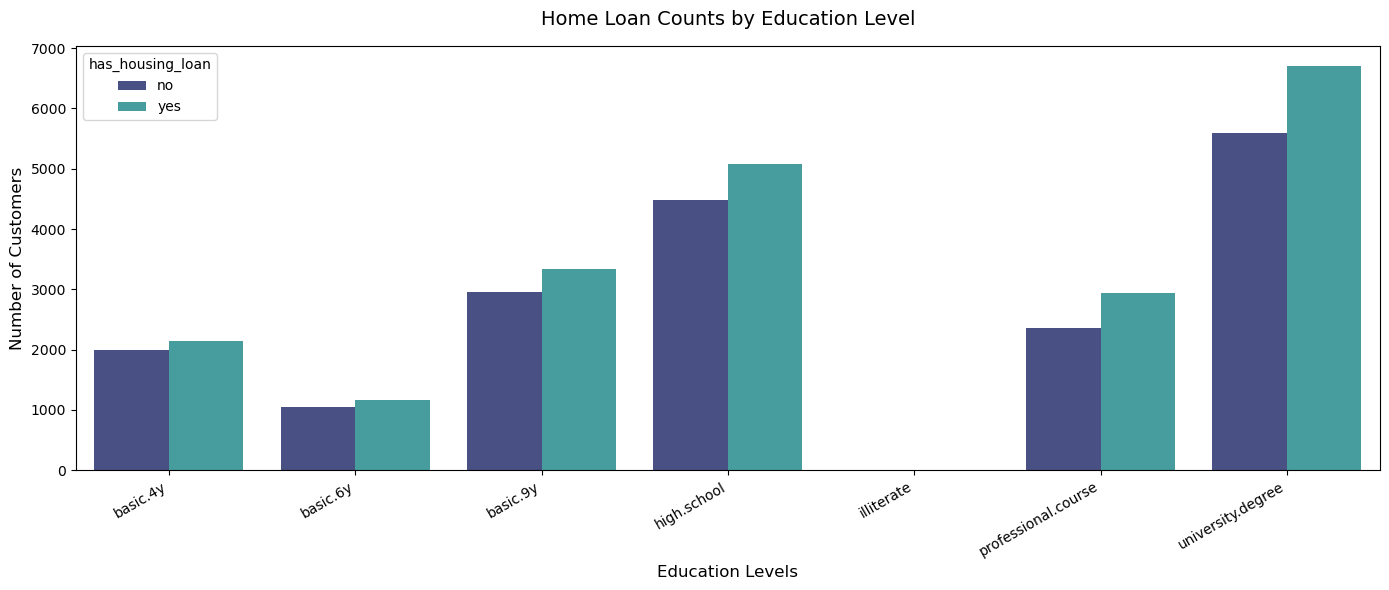

In [71]:
# Home Loans by education level

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=home_loan_by_education,
    x='education_level',    # education on x-axis
    y='count',              # bar height = count
    hue='has_housing_loan',          # grouped by cluster (0, 1, 2)
    palette='mako',
    errorbar=None
)

ax.set_title('Home Loan Counts by Education Level', fontsize=14, pad=15)
ax.set_xlabel('Education Levels', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [72]:
# Personal Loans by education level

personal_loan_by_education = df.groupby(['education_level', 'has_personal_loan'])['has_personal_loan'].size().reset_index(name='count')
personal_loan_by_education

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\577431742.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  personal_loan_by_education = df.groupby(['education_level', 'has_personal_loan'])['has_personal_loan'].size().reset_index(name='count')


,education_level,has_personal_loan,count
0,basic.4y,no,3498
1,basic.4y,yes,639
2,basic.6y,no,1878
3,basic.6y,yes,326
4,basic.9y,no,5360
5,basic.9y,yes,937
6,high.school,no,8072
7,high.school,yes,1481
8,illiterate,no,15
9,illiterate,yes,3


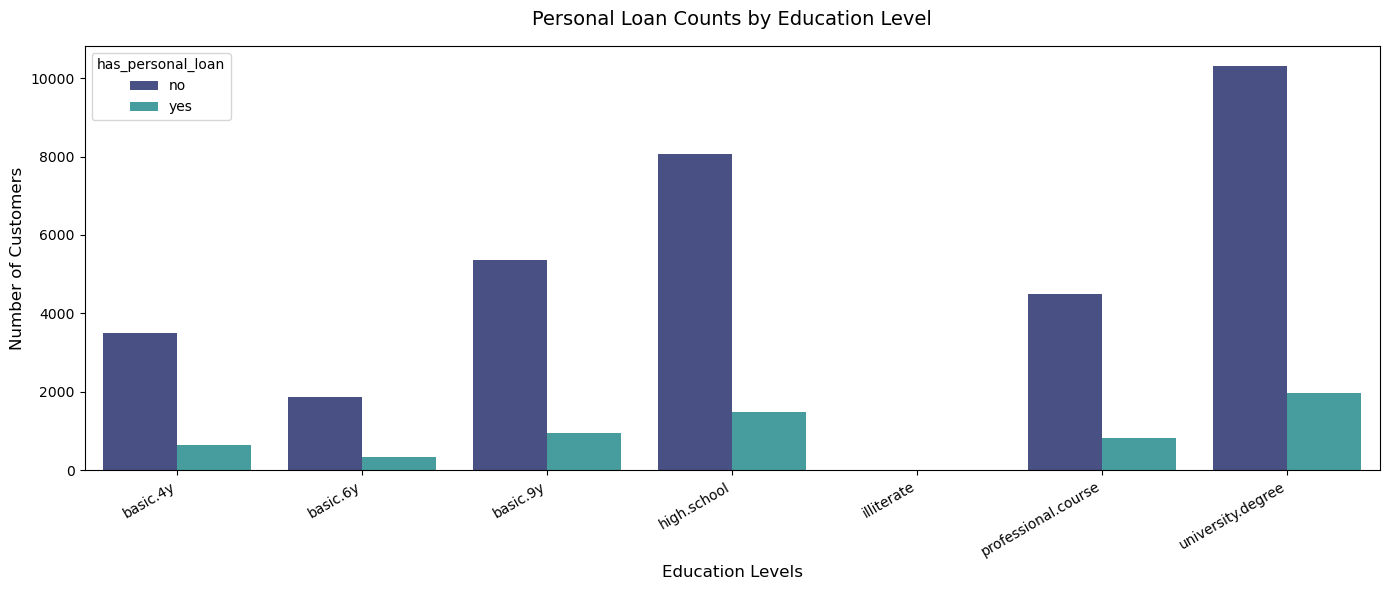

In [73]:
# Personal Loans by education level

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=personal_loan_by_education,
    x='education_level',    # education on x-axis
    y='count',              # bar height = count
    hue='has_personal_loan',          # grouped by cluster (0, 1, 2)
    palette='mako',
    errorbar=None
)

ax.set_title('Personal Loan Counts by Education Level', fontsize=14, pad=15)
ax.set_xlabel('Education Levels', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [74]:
df[df == 'unknown' ].count()

age                             0
job                             0
day_of_week                     0
campaign                        0
term_deposit_subscribed         0
has_housing_loan                0
has_personal_loan               0
default_status               8213
consumer_confidence_index       0
euribor_3mo_rate                0
marital_status                  0
education_level                 0
previous_contacted              0
communication_type              0
last_contact_month              0
last_contact_duration_sec       0
was_previously_contacted        0
positive_campaign_result        0
dtype: int64

In [75]:
# Mean euribor rates for subscribers vs non overall

sub_vs_euribor = df.groupby('term_deposit_subscribed')['euribor_3mo_rate'].mean()
sub_vs_euribor

term_deposit_subscribed
0    3.808003
1    2.129602
Name: euribor_3mo_rate, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3634201237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_vs_euribor.index, y=sub_vs_euribor.values, palette='mako')


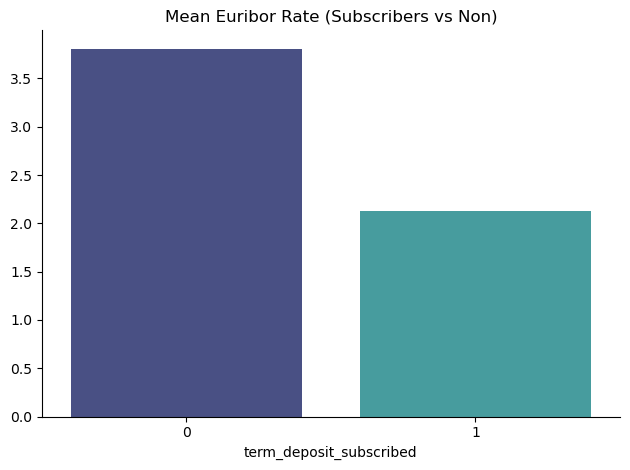

In [76]:
# Mean Euribor Rate for subscribers vs non subscribers

sns.barplot(x=sub_vs_euribor.index, y=sub_vs_euribor.values, palette='mako')
plt.title("Mean Euribor Rate (Subscribers vs Non)")
plt.tight_layout()
sns.despine()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3019579754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='term_deposit_subscribed', y='euribor_3mo_rate', palette='mako')


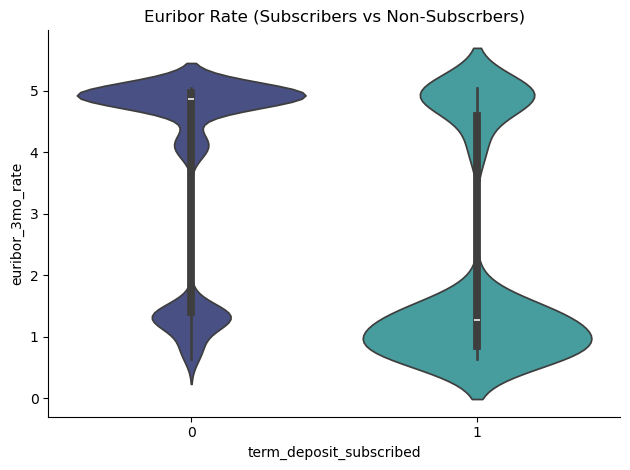

In [77]:
# Distributions for euribor rates for subscribers vs non subscribers

sns.violinplot(data=df, x='term_deposit_subscribed', y='euribor_3mo_rate', palette='mako')
plt.title('Euribor Rate (Subscribers vs Non-Subscrbers)')
plt.tight_layout()
sns.despine()
plt.show()

In [78]:
# Mean euribor rates for personal Loan overall

personal_loan_vs_euribor = df.groupby('has_personal_loan')['euribor_3mo_rate'].mean()
personal_loan_vs_euribor

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3831546685.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  personal_loan_vs_euribor = df.groupby('has_personal_loan')['euribor_3mo_rate'].mean()


has_personal_loan
no     3.618578
yes    3.619990
Name: euribor_3mo_rate, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\36628568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=personal_loan_vs_euribor.index, y=personal_loan_vs_euribor.values, palette='mako')


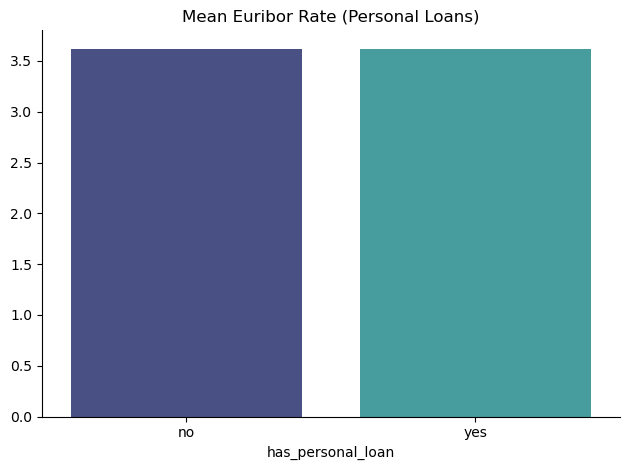

In [79]:
# Mean Euribor Rate for personal loan takers

sns.barplot(x=personal_loan_vs_euribor.index, y=personal_loan_vs_euribor.values, palette='mako')
plt.title("Mean Euribor Rate (Personal Loans)")
plt.tight_layout()
sns.despine()
plt.show()

In [80]:
# Mean euribor rates for has housing loan overall

home_loan_vs_euribor = df.groupby('has_housing_loan')['euribor_3mo_rate'].mean()
home_loan_vs_euribor

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\2658395552.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  home_loan_vs_euribor = df.groupby('has_housing_loan')['euribor_3mo_rate'].mean()


has_housing_loan
no     3.730326
yes    3.522654
Name: euribor_3mo_rate, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\4075435620.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=home_loan_vs_euribor.index, y=home_loan_vs_euribor.values, palette='mako')


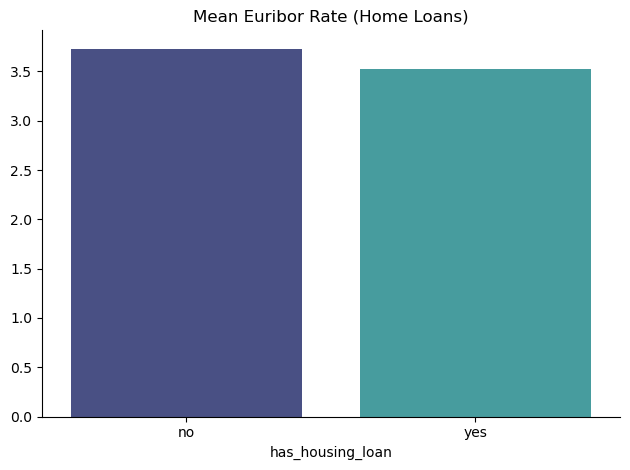

In [81]:
# Mean Euribor Rate for home loan takers

sns.barplot(x=home_loan_vs_euribor.index, y=home_loan_vs_euribor.values, palette='mako')
plt.title("Mean Euribor Rate (Home Loans)")
plt.tight_layout()
sns.despine()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\2407081302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='has_personal_loan', y='euribor_3mo_rate', palette='mako')


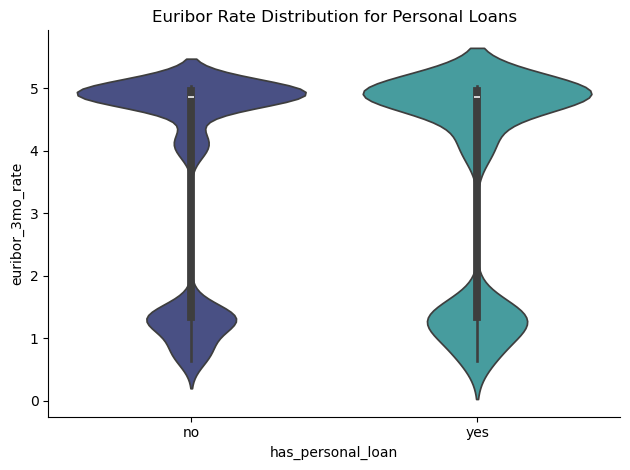

In [82]:
# Distributions for euribor rates personal loan takers

sns.violinplot(data=df, x='has_personal_loan', y='euribor_3mo_rate', palette='mako')
plt.title('Euribor Rate Distribution for Personal Loans')
plt.tight_layout()
sns.despine()
plt.show()

In [83]:
# Caluclate overall term deposit subscription rate

subscription_rate = df.groupby('term_deposit_subscribed')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])
subscription_rate.round(3) * 100

term_deposit_subscribed
0    88.7
1    11.3
Name: term_deposit_subscribed, dtype: float64

In [84]:
# Caluclate  term deposit subscription rate by edu level

edu_level_subscription_rate = df.groupby('education_level')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])
edu_level_subscription_rate = edu_level_subscription_rate.round(3) * 100
edu_level_subscription_rate = edu_level_subscription_rate.sort_values(ascending=False)
edu_level_subscription_rate

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3780214959.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_level_subscription_rate = df.groupby('education_level')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])


education_level
university.degree      30.9
high.school            24.0
basic.9y               15.8
professional.course    13.3
basic.4y               10.4
basic.6y                5.5
illiterate              0.0
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\2867616001.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=edu_level_subscription_rate.index, y=edu_level_subscription_rate.values, palette='mako', order=edu_level_subscription_rate.index)


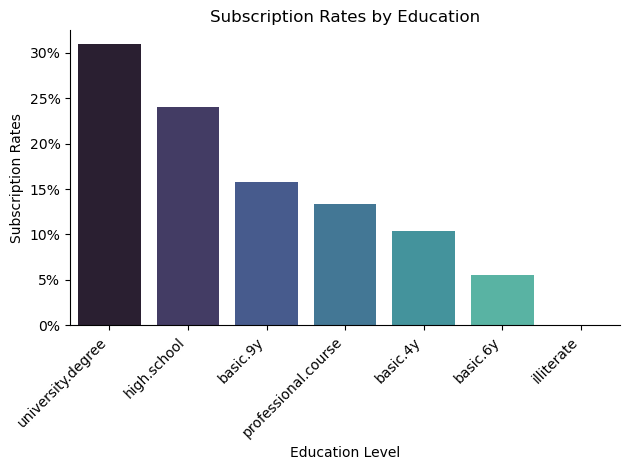

In [85]:
# Subscription rates by education level
import matplotlib.ticker as mticker

ax = sns.barplot(x=edu_level_subscription_rate.index, y=edu_level_subscription_rate.values, palette='mako', order=edu_level_subscription_rate.index)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.xticks(rotation=45, ha='right')
plt.title('Subscription Rates by Education')
plt.ylabel("Subscription Rates")
plt.xlabel("Education Level")
sns.despine()
plt.tight_layout()
plt.show()

In [86]:
# Calculate term deposit subscription rate by job

job_subscription_rate = df.groupby('job')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])
job_subscription_rate = job_subscription_rate.round(3) * 100
job_subscription_rate = job_subscription_rate.sort_values(ascending=False)
job_subscription_rate

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1551627068.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_subscription_rate = df.groupby('job')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])


job
admin.           25.6
blue-collar      22.6
technician       16.5
services          9.7
management        7.2
retired           4.2
entrepreneur      3.6
self-employed     3.5
housemaid         2.6
unemployed        2.5
student           2.1
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\944682805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=job_subscription_rate.index, y=job_subscription_rate.values, palette='mako', order=job_subscription_rate.index)


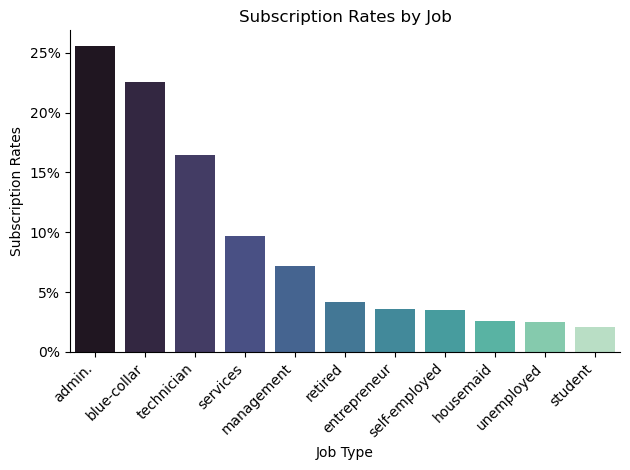

In [87]:
# Subscription rate by job type

ax = sns.barplot(x=job_subscription_rate.index, y=job_subscription_rate.values, palette='mako', order=job_subscription_rate.index)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.xticks(rotation=45, ha='right')
plt.title('Subscription Rates by Job')
plt.ylabel("Subscription Rates")
plt.xlabel("Job Type")
sns.despine()
plt.tight_layout()
plt.show()

In [88]:
# Calculate term deposit subscription rate by communucation type

comm_type_subscription_rate = df.groupby('communication_type')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])
comm_type_subscription_rate = comm_type_subscription_rate.round(3) * 100
comm_type_subscription_rate = comm_type_subscription_rate.sort_values(ascending=False)
comm_type_subscription_rate

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\11477364.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comm_type_subscription_rate = df.groupby('communication_type')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])


communication_type
cellular     63.7
telephone    36.3
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\2784743679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=comm_type_subscription_rate.index, y=comm_type_subscription_rate.values, palette='mako', order=comm_type_subscription_rate.index)


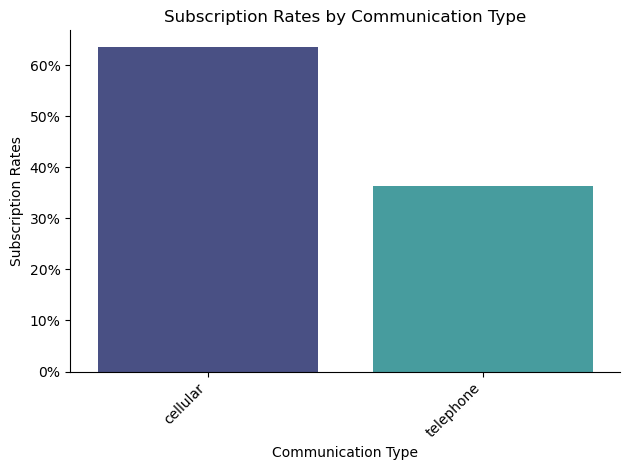

In [89]:
# Subscription Rate by communication type

ax = sns.barplot(x=comm_type_subscription_rate.index, y=comm_type_subscription_rate.values, palette='mako', order=comm_type_subscription_rate.index)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.xticks(rotation=45, ha='right')
plt.title('Subscription Rates by Communication Type')
plt.ylabel("Subscription Rates")
plt.xlabel("Communication Type")
sns.despine()
plt.tight_layout()
plt.show()

In [90]:
# Calculate term deposit subscription rate by communucation type

day_week_subscription_rate = df.groupby('day_of_week')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])
day_week_subscription_rate = day_week_subscription_rate.round(3) * 100
day_week_subscription_rate = day_week_subscription_rate.sort_values(ascending=False)
day_week_subscription_rate

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1006172428.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_week_subscription_rate = df.groupby('day_of_week')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])


day_of_week
thu    21.0
mon    20.7
wed    19.7
tue    19.6
fri    19.0
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3774724811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=day_week_subscription_rate.index, y=day_week_subscription_rate.values, palette='mako', order=week_list)


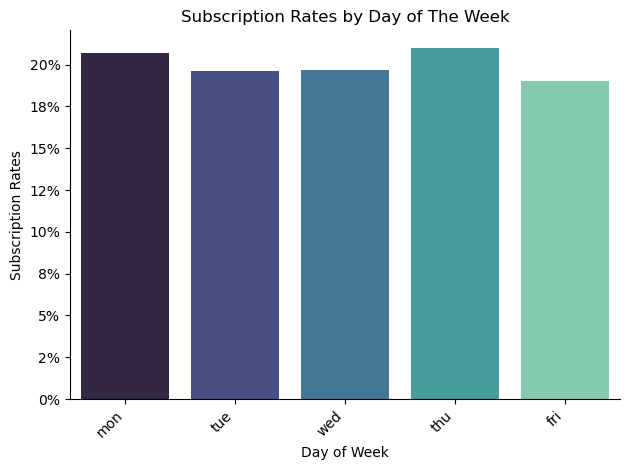

In [91]:
# Subscription Rate by day of week

week_list = ['mon', 'tue', 'wed', 'thu', 'fri']

ax = sns.barplot(x=day_week_subscription_rate.index, y=day_week_subscription_rate.values, palette='mako', order=week_list)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.xticks(rotation=45, ha='right')
plt.title('Subscription Rates by Day of The Week')
plt.ylabel("Subscription Rates")
plt.xlabel("Day of Week")
sns.despine()
plt.tight_layout()
plt.show()

In [92]:
# Calculate term deposit subscription rate by communucation type

last_mo_subscription_rate = df.groupby('last_contact_month')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])
last_mo_subscription_rate = last_mo_subscription_rate.round(3) * 100
last_mo_subscription_rate = last_mo_subscription_rate.sort_values(ascending=False)
last_mo_subscription_rate

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3691795613.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last_mo_subscription_rate = df.groupby('last_contact_month')['term_deposit_subscribed'].count() / len(df['term_deposit_subscribed'])


last_contact_month
may    33.3
jul    17.5
aug    15.0
jun    12.7
nov    10.1
apr     6.4
oct     1.7
sep     1.4
mar     1.3
dec     0.4
Name: term_deposit_subscribed, dtype: float64

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3089292995.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=last_mo_subscription_rate.index, y=last_mo_subscription_rate.values, palette='mako', order=last_mo_subscription_rate.index)


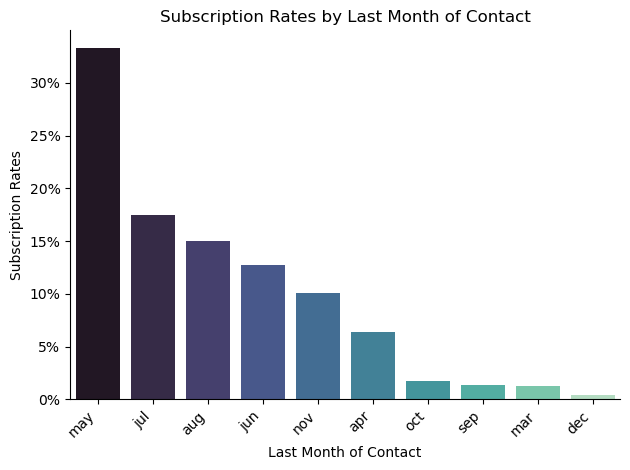

In [93]:
ax = sns.barplot(x=last_mo_subscription_rate.index, y=last_mo_subscription_rate.values, palette='mako', order=last_mo_subscription_rate.index)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.xticks(rotation=45, ha='right')
plt.title('Subscription Rates by Last Month of Contact')
plt.ylabel("Subscription Rates")
plt.xlabel("Last Month of Contact")
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\3168488170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='term_deposit_subscribed', y='age', palette='mako')


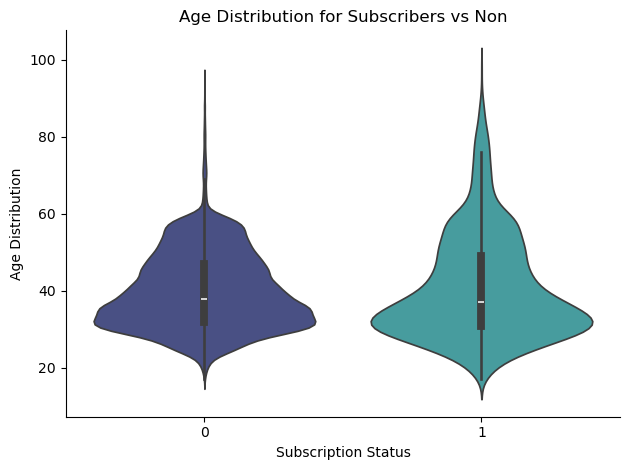

In [94]:
# Age distributions of subscribers

sns.violinplot(data=df, x='term_deposit_subscribed', y='age', palette='mako')
plt.title('Age Distribution for Subscribers vs Non')
plt.ylabel('Age Distribution')
plt.xlabel('Subscription Status')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1938159123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='term_deposit_subscribed', y='last_contact_duration_sec', palette='mako')


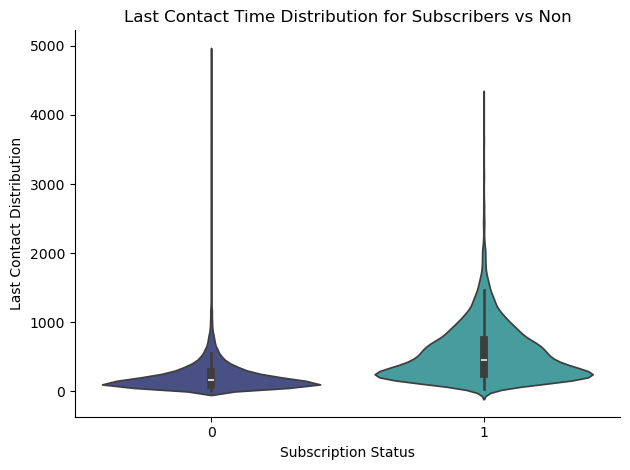

In [95]:
# Last Contact duration distributions of subscribers

sns.violinplot(data=df, x='term_deposit_subscribed', y='last_contact_duration_sec', palette='mako')
plt.title('Last Contact Time Distribution for Subscribers vs Non')
plt.ylabel('Last Contact Distribution')
plt.xlabel('Subscription Status')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\362770787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='term_deposit_subscribed', y='previous_contacted', palette='mako')


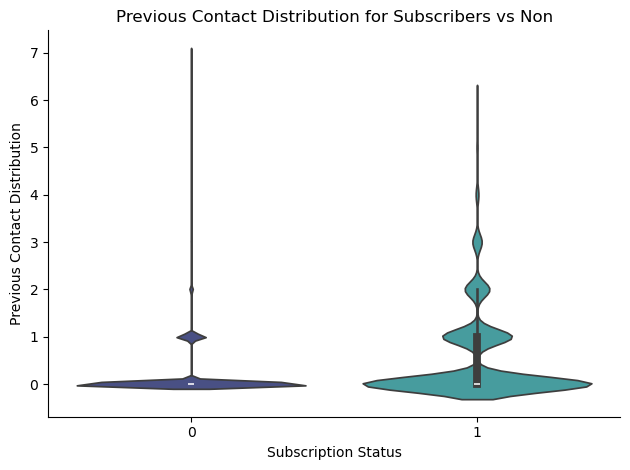

In [96]:
# Previous Contact distributions of subscribers

sns.violinplot(data=df, x='term_deposit_subscribed', y='previous_contacted', palette='mako')
plt.title('Previous Contact Distribution for Subscribers vs Non')
plt.ylabel('Previous Contact Distribution')
plt.xlabel('Subscription Status')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\12729953.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_subscription_rate = df.groupby('job')['term_deposit_subscribed'].mean().round(3) * 100
C:\Users\brand\AppData\Local\Temp\ipykernel_6232\12729953.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


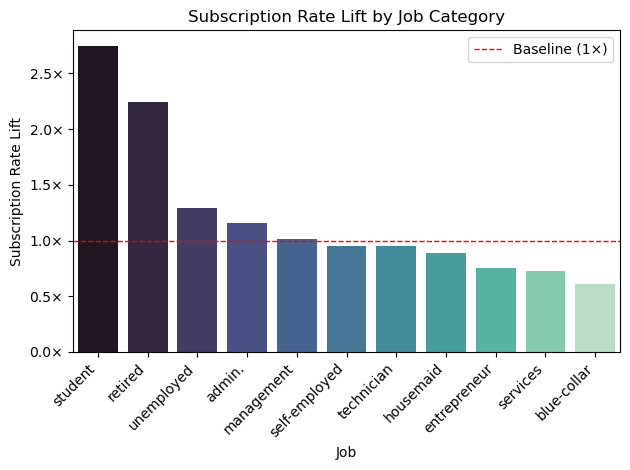

In [97]:
# Lift by job type

# Calculate lift for job
overall_rate = df['term_deposit_subscribed'].mean() * 100

job_subscription_rate = df.groupby('job')['term_deposit_subscribed'].mean().round(3) * 100
job_lift = (job_subscription_rate / overall_rate).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots()

sns.barplot(
    x=job_lift.index,
    y=job_lift.values,
    order=job_lift.index,
    ax=ax,
    palette='mako'
)

ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Baseline (1×)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}×'))
ax.set_xlabel('Job')
ax.set_ylabel('Subscription Rate Lift')
ax.set_title('Subscription Rate Lift by Job Category')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1153517165.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_subscription_rate = df.groupby('education_level')['term_deposit_subscribed'].mean().round(3) * 100
C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1153517165.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  valid_groups = df.groupby('education_level')['term_deposit_subscribed'].count()
C:\Users\brand\AppData\Local\Temp\ipykernel_6232\1153517165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and

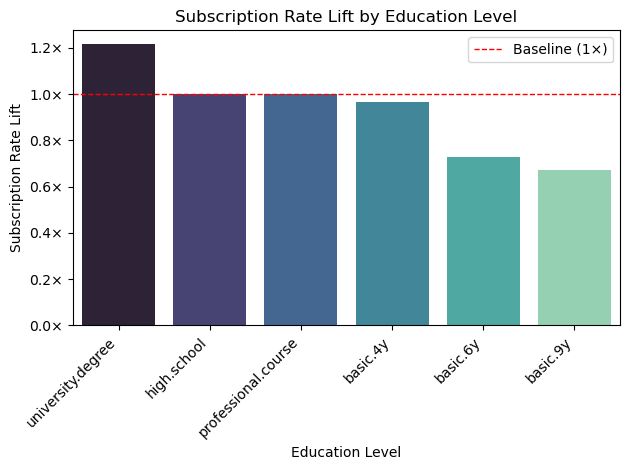

In [98]:
# Lift by education level

overall_rate = df['term_deposit_subscribed'].mean() * 100

edu_subscription_rate = df.groupby('education_level')['term_deposit_subscribed'].mean().round(3) * 100
edu_lift = (edu_subscription_rate / overall_rate).sort_values(ascending=False)

# Filter out small groups
min_count = 50
valid_groups = df.groupby('education_level')['term_deposit_subscribed'].count()
valid_groups = valid_groups[valid_groups >= min_count].index
edu_lift_filtered = edu_lift[edu_lift.index.isin(valid_groups)]

# Plot
fig, ax = plt.subplots()

sns.barplot(
    x=edu_lift_filtered.index,
    y=edu_lift_filtered.values,
    order=edu_lift_filtered.index,
    ax=ax,
    palette='mako'
)

ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Baseline (1×)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}×'))
ax.set_xlabel('Education Level')
ax.set_ylabel('Subscription Rate Lift')
ax.set_title('Subscription Rate Lift by Education Level')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()